# BrainClamp analysis

Shun, 04/15/26

## Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.io
import h5py
import os
import tqdm
import mat73

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# root_dir = '/Users/shunli/Projects/BrainClamp/data/'
root_dir = '/Volumes/Neurobio/MICROSCOPE/Shun/Project clamping/Recordings/202604-BiPOLES'

session_name = '20260413-SL431-Random1Ctrl_g0'
timeseries_file_path = os.path.join(root_dir, f'{session_name}', f'timeseries_{session_name}.mat')
behavior_file_path = os.path.join(root_dir, f'{session_name}', f'behavior_{session_name}.mat')
sync_file_path = os.path.join(root_dir, f'{session_name}', f'sync_{session_name}.mat')

# Load the MATLAB file
behavior_mat = ndap.load_mat(behavior_file_path)
print(f'Loaded behavior: {behavior_mat.keys()}')
timeseries_mat = ndap.load_timeseries_mat(timeseries_file_path)
print(f'Loaded timeseries: {timeseries_mat.keys()}')
sync_mat = ndap.load_mat(sync_file_path)
print(f'Loaded sync: {sync_mat.keys()}')

# Optional: load data
# data_file_path = os.path.join(root_dir, f'{session_name}', f'data_{session_name}.mat')
# data_mat = ndap.load_mat(data_file_path)
# print(f'Loaded data: {data_mat.keys()}')

Loaded behavior: dict_keys(['airpuffIdx', 'allTrials', 'blockTable', 'eventTable', 'session', 'sessionName', 'trialTable', 'trials', 'waterIdx', 'waterLickIdx'])
Loaded timeseries: dict_keys(['NAc_left', 'NAc_right', 'blueClamp', 'redClamp'])
Loaded sync: dict_keys(['params', 'session', 'sessionName'])


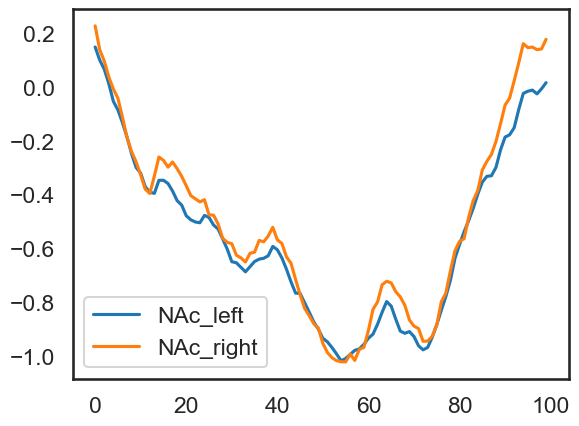

In [3]:
NAc_left = timeseries_mat['NAc_left']['data']
NAc_right = timeseries_mat['NAc_right']['data']

photometry_fs = timeseries_mat['NAc_left']['finalFs']
params = sync_mat['params']

# Plot the first 1000 data points of both signals
plt.plot(NAc_left[:100])
plt.plot(NAc_right[:100])
plt.legend(['NAc_left', 'NAc_right'])

## Plot water response

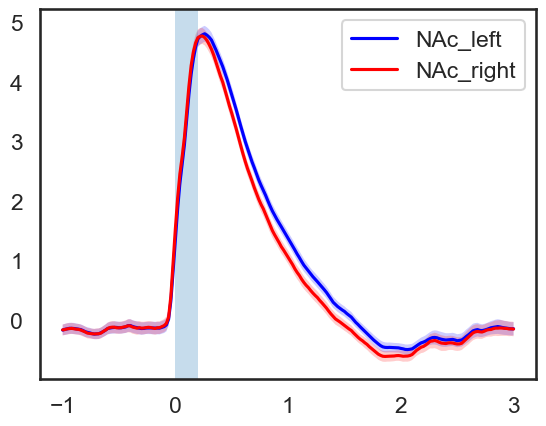

In [6]:
waterIdx = behavior_mat['waterLickIdx']

event_label = 'water'
time_range = (-1,3)       # in sec
event_color = 'tab:blue'
event_duration = 0.2        # in sec

water_response_left = ndap.get_traces(NAc_left, waterIdx, time_range=time_range,
                                        signal_system='LJ', signal_fs=photometry_fs, params=params)
water_response_right = ndap.get_traces(NAc_right, waterIdx, time_range=time_range,
                                        signal_system='LJ', signal_fs=photometry_fs, params=params)

ndap.plot_sem(water_response_left[0], water_response_left[1], label='NAc_left', color='blue')
ndap.plot_sem(water_response_right[0], water_response_right[1], label='NAc_right', color='red')
plt.axvspan(0, event_duration, facecolor=event_color, alpha=0.25, edgecolor='none')
plt.legend()
plt.show()